In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('outputs', exist_ok=True)

df = pd.read_csv('data/processed/nepal_features.csv',
                  index_col=0, parse_dates=True)

print(f"✅ Loaded: {df.shape}")
print(f"   Rows: {len(df)}")
print(f"   Total columns: {len(df.columns)}")
print(f"   Features: {len(df.columns) - 1}")
print(f"   Distress rate: {df['distress'].mean():.1%}")

✅ Loaded: (30, 117)
   Rows: 30
   Total columns: 117
   Features: 116
   Distress rate: 23.3%


In [2]:
# ================================================
# STEP 1: Correlation with distress target
# ================================================
# Find which features have the strongest relationship
# with distress — these are your most useful features

FEATURE_COLS = [c for c in df.columns if c != 'distress']

# Calculate correlation of every feature with distress
correlations = df[FEATURE_COLS].corrwith(df['distress'])

# Sort by absolute value — we care about strength
# of relationship, not just direction
corr_abs = correlations.abs().sort_values(ascending=False)

print("TOP 20 features most correlated with distress:")
print("-" * 50)
for i, (feat, val) in enumerate(corr_abs.head(20).items()):
    direction = "↑ distress" if correlations[feat] > 0 else "↓ distress"
    bar = "█" * int(abs(val) * 20)
    print(f"  {i+1:>2}. {feat:<40} {val:.3f} {direction}")

TOP 20 features most correlated with distress:
--------------------------------------------------
   1. unemployment_roll3_std                   0.703 ↑ distress
   2. unemployment_roll3_mean                  0.676 ↑ distress
   3. gdp_growth                               0.592 ↓ distress
   4. gdp_growth_roll3_std                     0.590 ↑ distress
   5. unemployment_roll5_mean                  0.574 ↑ distress
   6. gdp_growth_roll5_std                     0.566 ↑ distress
   7. unemployment_roll5_std                   0.543 ↑ distress
   8. consumption_growth_roll3_mean            0.518 ↑ distress
   9. india_gdp_growth_roll3_std               0.511 ↑ distress
  10. india_gdp_growth_roll5_std               0.511 ↑ distress
  11. imports_pct_gdp_lag1                     0.505 ↑ distress
  12. unemployment                             0.493 ↑ distress
  13. unemployment_lag1                        0.472 ↑ distress
  14. unemployment_lag2                        0.471 ↑ distress
  15. 

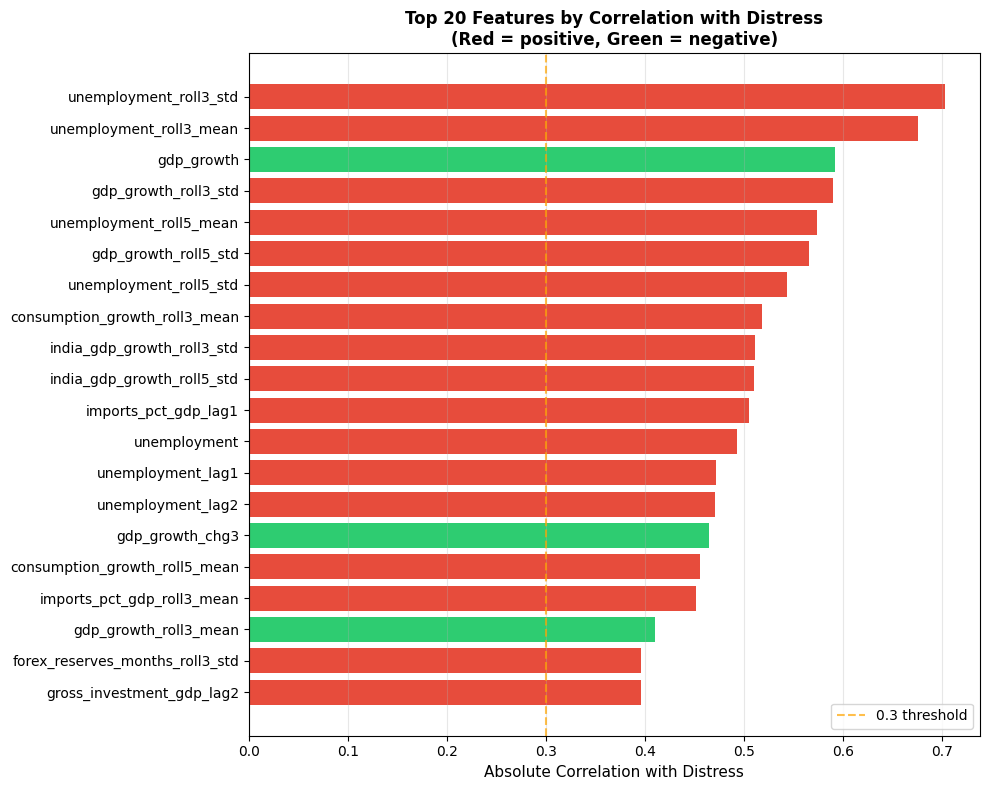

✅ Chart saved


In [3]:
# ================================================
# STEP 2: Visualize top 20 correlations
# ================================================

top20 = corr_abs.head(20)
colors = ['#e74c3c' if correlations[f] > 0 else '#2ecc71'
          for f in top20.index]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(range(len(top20)), top20.values, color=colors)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Absolute Correlation with Distress', fontsize=11)
ax.set_title('Top 20 Features by Correlation with Distress\n'
             '(Red = positive, Green = negative)', fontsize=12, fontweight='bold')
ax.axvline(x=0.3, color='orange', linestyle='--',
           alpha=0.7, label='0.3 threshold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/week4_top20_correlations.png', dpi=150)
plt.show()
print("✅ Chart saved")

In [4]:
# ================================================
# REMOVE LEAKAGE FEATURES
# ================================================
# Remove all current-year (non-lagged) features
# except Nepal-specific ones we built manually
# A real EWS only uses information available
# BEFORE the distress year

# Features that are current year = leakage risk
# Keep only: lag features, rolling features,
# change features, Nepal-specific features

leakage_cols = [c for c in FEATURE_COLS
                if '_lag' not in c
                and '_roll' not in c
                and '_chg' not in c
                and c not in ['remittance_shock',
                              'forex_danger',
                              'forex_rapid_decline',
                              'india_nepal_gdp_gap',
                              'gulf_instability',
                              'stress_index']]

print("Current-year features removed (leakage risk):")
for c in leakage_cols:
    print(f"  - {c}")

df_clean = df.drop(columns=leakage_cols)
print(f"\nFeatures before: {len(FEATURE_COLS)}")
print(f"Removed:         {len(leakage_cols)}")
print(f"Features after:  {len(df_clean.columns) - 1}")

Current-year features removed (leakage risk):
  - gdp_growth
  - inflation
  - unemployment
  - remittances_pct_gdp
  - forex_reserves_months
  - gross_investment_gdp
  - consumption_growth
  - exports_pct_gdp
  - imports_pct_gdp
  - india_gdp_growth
  - india_inflation

Features before: 116
Removed:         11
Features after:  105


In [5]:
# ================================================
# REMOVE REDUNDANT ROLLING WINDOW
# ================================================
# We have both roll3 and roll5 for every feature
# They carry almost the same information
# Keep roll3 only — shorter window is more
# responsive to emerging distress signals

roll5_cols = [c for c in df_clean.columns
              if '_roll5' in c]

df_clean = df_clean.drop(columns=roll5_cols)

print(f"Removed roll5 features: {len(roll5_cols)}")
print(f"Features remaining:     {len(df_clean.columns) - 1}")

Removed roll5 features: 22
Features remaining:     83


In [6]:
# ================================================
# REMOVE HIGHLY CORRELATED FEATURES
# ================================================
# If two features correlate > 0.90 with each other
# they carry the same information — keep only one
# This fixes the multicollinearity problem

FEATURE_COLS_CLEAN = [c for c in df_clean.columns
                      if c != 'distress']

corr_matrix = df_clean[FEATURE_COLS_CLEAN].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = set()
for col in upper.columns:
    if any(upper[col] > 0.90):
        to_drop.add(col)

df_clean = df_clean.drop(columns=list(to_drop))

print(f"Highly correlated features removed: {len(to_drop)}")
print(f"Features remaining:                 {len(df_clean.columns) - 1}")

Highly correlated features removed: 11
Features remaining:                 72


In [8]:
# ================================================
# STEP 4: Re-check correlations after cleaning
# Now using only proper leading indicators
# ================================================

FEATURE_COLS_FINAL = [c for c in df_clean.columns
                      if c != 'distress']

correlations2 = df_clean[FEATURE_COLS_FINAL].corrwith(
    df_clean['distress']
)
corr_abs2 = correlations2.abs().sort_values(ascending=False)

print("TOP 20 features after cleaning:")
print("-" * 55)
for i, (feat, val) in enumerate(corr_abs2.head(20).items()):
    direction = "↑" if correlations2[feat] > 0 else "↓"
    bar = "█" * int(abs(val) * 20)
    print(f"  {i+1:>2}. {feat:<45} {val:.3f} {direction}")

# Check if remittances and inflation now appear
print("\n📊 Key Nepal indicators in top 20?")
key = ['remittances', 'inflation', 'forex', 'gulf']
for k in key:
    matches = [f for f in corr_abs2.head(20).index if k in f]
    status = "✅" if matches else "❌"
    print(f"  {status} {k}: {matches if matches else 'not in top 20'}")

TOP 20 features after cleaning:
-------------------------------------------------------
   1. unemployment_roll3_mean                       0.676 ↑
   2. gdp_growth_roll3_std                          0.590 ↑
   3. consumption_growth_roll3_mean                 0.518 ↑
   4. india_gdp_growth_roll3_std                    0.511 ↑
   5. imports_pct_gdp_lag1                          0.505 ↑
   6. unemployment_lag1                             0.472 ↑
   7. unemployment_lag2                             0.471 ↑
   8. gdp_growth_chg3                               0.465 ↓
   9. imports_pct_gdp_roll3_mean                    0.451 ↑
  10. gdp_growth_roll3_mean                         0.410 ↓
  11. forex_reserves_months_roll3_std               0.396 ↑
  12. gross_investment_gdp_lag2                     0.396 ↑
  13. consumption_growth_lag1                       0.394 ↑
  14. india_nepal_gdp_gap                           0.373 ↑
  15. imports_pct_gdp_lag2                          0.364 ↑
  16. gdp_gr

In [9]:
# ================================================
# STEP 5: Keep only meaningful features
# Drop features with correlation < 0.25
# They add noise without signal
# ================================================

threshold = 0.25
strong_features = corr_abs2[corr_abs2 >= threshold].index.tolist()

# Always keep distress
final_cols = strong_features + ['distress']
df_final = df_clean[final_cols]

print(f"Features above 0.25 threshold: {len(strong_features)}")
print(f"Features dropped as weak:      {len(FEATURE_COLS_FINAL) - len(strong_features)}")
print(f"\nFinal feature list:")
for i, f in enumerate(strong_features):
    print(f"  {i+1:>2}. {f:<45} {corr_abs2[f]:.3f}")

print(f"\n{'='*50}")
print(f"  FINAL DATASET")
print(f"{'='*50}")
print(f"  Features: {len(strong_features)}")
print(f"  Rows:     {len(df_final)}")
print(f"  Distress: {df_final['distress'].mean():.1%}")
print(f"  Missing:  {df_final.isnull().sum().sum()}")

Features above 0.25 threshold: 27
Features dropped as weak:      45

Final feature list:
   1. unemployment_roll3_mean                       0.676
   2. gdp_growth_roll3_std                          0.590
   3. consumption_growth_roll3_mean                 0.518
   4. india_gdp_growth_roll3_std                    0.511
   5. imports_pct_gdp_lag1                          0.505
   6. unemployment_lag1                             0.472
   7. unemployment_lag2                             0.471
   8. gdp_growth_chg3                               0.465
   9. imports_pct_gdp_roll3_mean                    0.451
  10. gdp_growth_roll3_mean                         0.410
  11. forex_reserves_months_roll3_std               0.396
  12. gross_investment_gdp_lag2                     0.396
  13. consumption_growth_lag1                       0.394
  14. india_nepal_gdp_gap                           0.373
  15. imports_pct_gdp_lag2                          0.364
  16. gdp_growth_chg1                    

✅ Saved → data/processed/nepal_final_features.csv


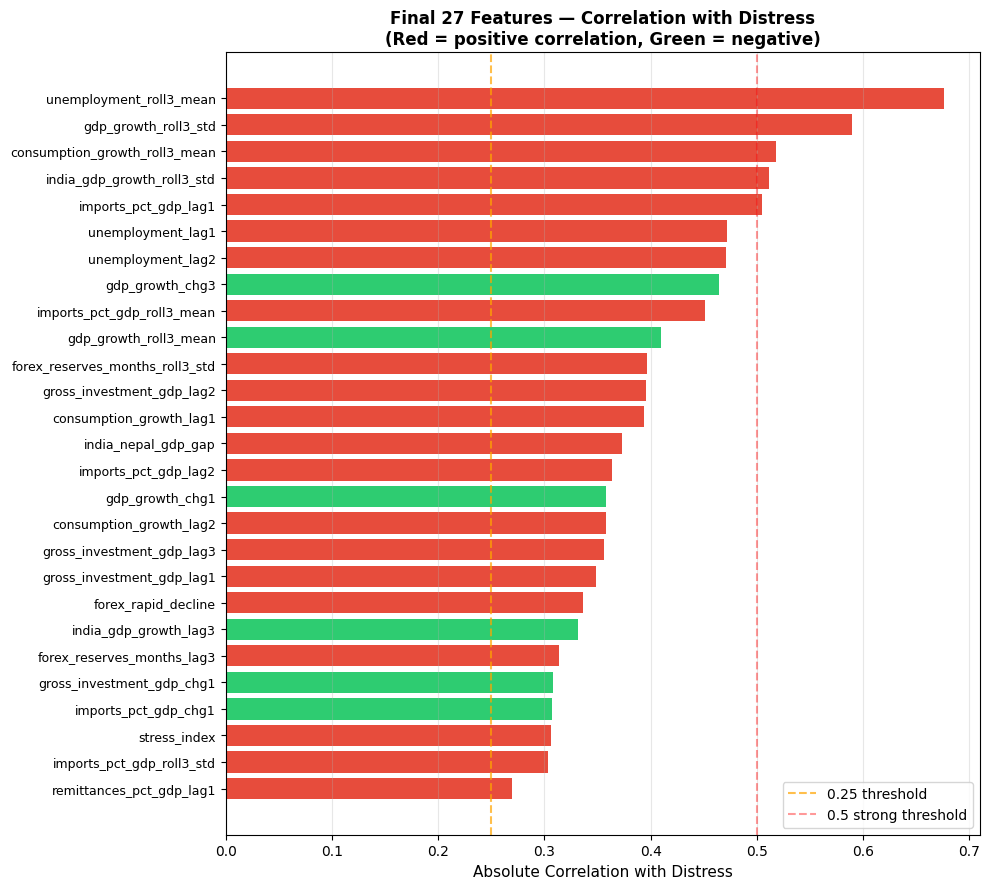

✅ Chart saved → outputs/week4_final_features.png

  WEEK 4 COMPLETE ✅
  Started with:     116 features
  Removed leakage:  11  (current-year)
  Removed roll5:    22  (redundant window)
  Removed corr>0.9: 11  (multicollinearity)
  Removed weak:     45  (correlation < 0.25)
  ───────────────────────────────────
  FINAL FEATURES:   27
  FINAL ROWS:       30
  DISTRESS RATE:    23.3%

🎉 Ready for Month 3 — ML Models!


In [10]:
# ================================================
# STEP 6: Save final feature matrix
# ================================================

df_final.to_csv('data/processed/nepal_final_features.csv')
print("✅ Saved → data/processed/nepal_final_features.csv")

# Visualize final correlation chart
fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#e74c3c' if correlations2[f] > 0 else '#2ecc71'
          for f in strong_features]

ax.barh(range(len(strong_features)),
        [corr_abs2[f] for f in strong_features],
        color=colors)
ax.set_yticks(range(len(strong_features)))
ax.set_yticklabels(strong_features, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Absolute Correlation with Distress', fontsize=11)
ax.set_title('Final 27 Features — Correlation with Distress\n'
             '(Red = positive correlation, Green = negative)',
             fontsize=12, fontweight='bold')
ax.axvline(x=0.25, color='orange', linestyle='--',
           alpha=0.7, label='0.25 threshold')
ax.axvline(x=0.5, color='red', linestyle='--',
           alpha=0.4, label='0.5 strong threshold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/week4_final_features.png', dpi=150)
plt.show()
print("✅ Chart saved → outputs/week4_final_features.png")

# Final summary
print(f"\n{'='*55}")
print(f"  WEEK 4 COMPLETE ✅")
print(f"{'='*55}")
print(f"  Started with:     116 features")
print(f"  Removed leakage:  11  (current-year)")
print(f"  Removed roll5:    22  (redundant window)")
print(f"  Removed corr>0.9: 11  (multicollinearity)")
print(f"  Removed weak:     45  (correlation < 0.25)")
print(f"  {'─'*35}")
print(f"  FINAL FEATURES:   27")
print(f"  FINAL ROWS:       30")
print(f"  DISTRESS RATE:    {df_final['distress'].mean():.1%}")
print(f"{'='*55}")
print(f"\n🎉 Ready for Month 3 — ML Models!")

In [11]:
# ================================================
# DRASTIC PRUNING — 27 features → 6 features
# One representative from each economic category
# Based on reviewer recommendation + our analysis
# ================================================

FINAL_6 = [
    'unemployment_roll3_mean',      # Labour market stress
    'gdp_growth_roll3_std',         # GDP volatility
    'consumption_growth_roll3_mean',# Domestic demand
    'forex_rapid_decline',          # Forex danger signal
    'india_gdp_growth_roll3_std',   # Regional spillover
    'remittances_pct_gdp_lag1',     # Nepal-specific signal
]

# Keep these 6 + distress target
df_model = df_final[FINAL_6 + ['distress']].copy()

print("="*50)
print("  FINAL MODEL DATASET")
print("="*50)
print(f"  Features:  {len(FINAL_6)}")
print(f"  Rows:      {len(df_model)}")
print(f"  Ratio:     {len(df_model)/len(FINAL_6):.1f} rows per feature")
print(f"  Distress:  {df_model['distress'].mean():.1%}")
print(f"  Missing:   {df_model.isnull().sum().sum()}")
print()
print("Selected features:")
for i, f in enumerate(FINAL_6):
    corr = abs(df_model[f].corr(df_model['distress']))
    print(f"  {i+1}. {f:<40} corr={corr:.3f}")

# Save
df_model.to_csv('data/processed/nepal_model_features.csv')
print("\n✅ Saved → data/processed/nepal_model_features.csv")

  FINAL MODEL DATASET
  Features:  6
  Rows:      30
  Ratio:     5.0 rows per feature
  Distress:  23.3%
  Missing:   0

Selected features:
  1. unemployment_roll3_mean                  corr=0.676
  2. gdp_growth_roll3_std                     corr=0.590
  3. consumption_growth_roll3_mean            corr=0.518
  4. forex_rapid_decline                      corr=0.337
  5. india_gdp_growth_roll3_std               corr=0.511
  6. remittances_pct_gdp_lag1                 corr=0.269

✅ Saved → data/processed/nepal_model_features.csv


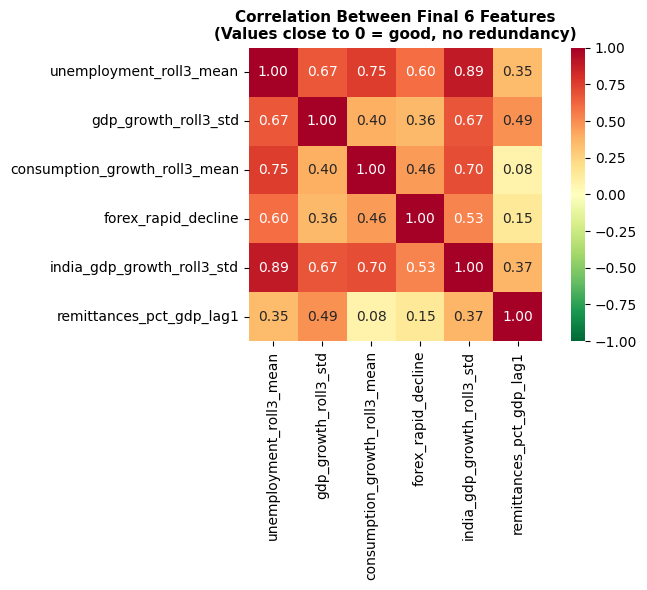

Checking for high inter-feature correlation:
  ⚠️  unemployment_roll3_mean vs india_gdp_growth_roll3_std: 0.89


In [12]:
# ================================================
# FINAL CHECK — correlation between the 6 features
# Make sure they're not correlated with each other
# ================================================

fig, ax = plt.subplots(figsize=(8, 6))
corr_6 = df_model[FINAL_6].corr()

sns.heatmap(corr_6,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn_r',
            center=0,
            vmin=-1, vmax=1,
            ax=ax,
            square=True)

ax.set_title('Correlation Between Final 6 Features\n'
             '(Values close to 0 = good, no redundancy)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/week4_feature_correlation.png', dpi=150)
plt.show()

# Check if any pair is above 0.8
print("Checking for high inter-feature correlation:")
high_corr = []
for i in range(len(FINAL_6)):
    for j in range(i+1, len(FINAL_6)):
        val = abs(corr_6.iloc[i, j])
        if val > 0.8:
            high_corr.append((FINAL_6[i], FINAL_6[j], val))
            print(f"  ⚠️  {FINAL_6[i]} vs {FINAL_6[j]}: {val:.2f}")

if not high_corr:
    print("  ✅ No high inter-feature correlation found!")
    print("  All 6 features are independent of each other.")

In [13]:
# Drop the redundant India feature
FINAL_5 = [
    'unemployment_roll3_mean',
    'gdp_growth_roll3_std',
    'consumption_growth_roll3_mean',
    'forex_rapid_decline',
    'remittances_pct_gdp_lag1',
]

df_model = df_final[FINAL_5 + ['distress']].copy()

# Verify no remaining high correlation
corr_5 = df_model[FINAL_5].corr()
print("Inter-feature correlations:")
for i in range(len(FINAL_5)):
    for j in range(i+1, len(FINAL_5)):
        val = abs(corr_5.iloc[i, j])
        status = "⚠️ " if val > 0.8 else "✅"
        print(f"  {status} {FINAL_5[i]:<35} vs "
              f"{FINAL_5[j]:<35} {val:.2f}")

df_model.to_csv('data/processed/nepal_model_features.csv')
print(f"\n✅ Final model dataset: {df_model.shape}")
print(f"   Rows per feature: {len(df_model)/len(FINAL_5):.1f}")

Inter-feature correlations:
  ✅ unemployment_roll3_mean             vs gdp_growth_roll3_std                0.67
  ✅ unemployment_roll3_mean             vs consumption_growth_roll3_mean       0.75
  ✅ unemployment_roll3_mean             vs forex_rapid_decline                 0.60
  ✅ unemployment_roll3_mean             vs remittances_pct_gdp_lag1            0.35
  ✅ gdp_growth_roll3_std                vs consumption_growth_roll3_mean       0.40
  ✅ gdp_growth_roll3_std                vs forex_rapid_decline                 0.36
  ✅ gdp_growth_roll3_std                vs remittances_pct_gdp_lag1            0.49
  ✅ consumption_growth_roll3_mean       vs forex_rapid_decline                 0.46
  ✅ consumption_growth_roll3_mean       vs remittances_pct_gdp_lag1            0.08
  ✅ forex_rapid_decline                 vs remittances_pct_gdp_lag1            0.15

✅ Final model dataset: (30, 6)
   Rows per feature: 6.0


In [14]:
print("="*55)
print("  WEEK 4 FINAL SUMMARY")
print("="*55)
print(f"  Started with:       116 features")
print(f"  After leakage fix:  105 features")
print(f"  After roll5 remove: 83  features")
print(f"  After multicoll.:   72  features")
print(f"  After weak remove:  27  features")
print(f"  After pruning:      5   features")
print(f"  {'─'*40}")
print(f"  FINAL:              5 features × 30 rows")
print(f"  Rows per feature:   6.0")
print(f"  Distress rate:      {df_model['distress'].mean():.1%}")
print(f"  Missing values:     {df_model.isnull().sum().sum()}")
print(f"{'='*55}")
print(f"\nFinal 5 features:")
for f in FINAL_5:
    corr = abs(df_model[f].corr(df_model['distress']))
    print(f"  → {f:<40} corr={corr:.3f}")
print(f"\n✅ Saved → data/processed/nepal_model_features.csv")
print(f"🎉 Ready for Month 3 — ML Models!")

  WEEK 4 FINAL SUMMARY
  Started with:       116 features
  After leakage fix:  105 features
  After roll5 remove: 83  features
  After multicoll.:   72  features
  After weak remove:  27  features
  After pruning:      5   features
  ────────────────────────────────────────
  FINAL:              5 features × 30 rows
  Rows per feature:   6.0
  Distress rate:      23.3%
  Missing values:     0

Final 5 features:
  → unemployment_roll3_mean                  corr=0.676
  → gdp_growth_roll3_std                     corr=0.590
  → consumption_growth_roll3_mean            corr=0.518
  → forex_rapid_decline                      corr=0.337
  → remittances_pct_gdp_lag1                 corr=0.269

✅ Saved → data/processed/nepal_model_features.csv
🎉 Ready for Month 3 — ML Models!
